###  1.Data Handling

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder

In [3]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "insurance.csv" 

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "mirichoi0218/insurance",
  file_path,
)

print("First 5 records:", df.head())

c:\Users\VNSP8859\Data Learning\medical-insurance-cost-prediction\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\VNSP8859\AppData\Local\Temp\ipykernel_16948\3906283397.py:6: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


First 5 records:    age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [ ]:
df.to_csv('../dataset/insurance_data.csv', index=False)

In [4]:
df=pd.DataFrame(df,index=None)
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


### 2.EDA

In [6]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


<div style="font-size: 85%;">


* **`age`:** Ranges from **18 to 64** years old. The mean and median are both around **39**, indicating a perfectly balanced age distribution.
* **`bmi`:** The average BMI is **30.66**, which crosses into the *obese* category. More than 50% of the population in this dataset has a BMI above 30.4.
* **`children`:** Most individuals have few children, with a median of **1 child** and a maximum of **5**.
* **`charges` (Target):** Highly **right-skewed** (Mean **\$13.2k** > Median **\$9.3k**). 


</div>

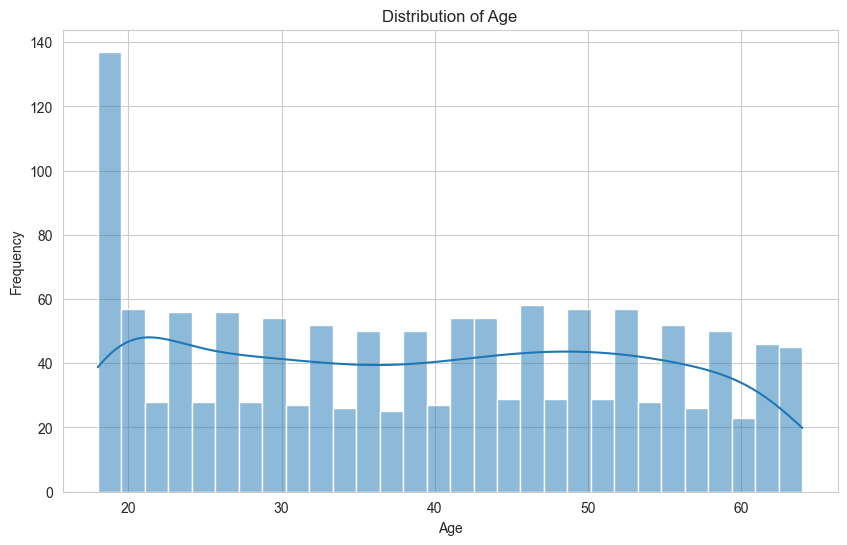

In [7]:
#Age column
sns.set_style('whitegrid')
plt.figure(figsize=(10,6))
sns.histplot(df['age'], bins=30, kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

<div style="font-size: 85%;">

* **Uniform Distribution (almost):** Except for the youngest group, the population is relatively **uniformly distributed** across all ages from 20 to 64, with each age bracket maintaining a steady frequency of around 40–60 individuals.

* **Data Implications:** The dataset provides a healthy spread for analyzing middle-aged and older demographics

</div>

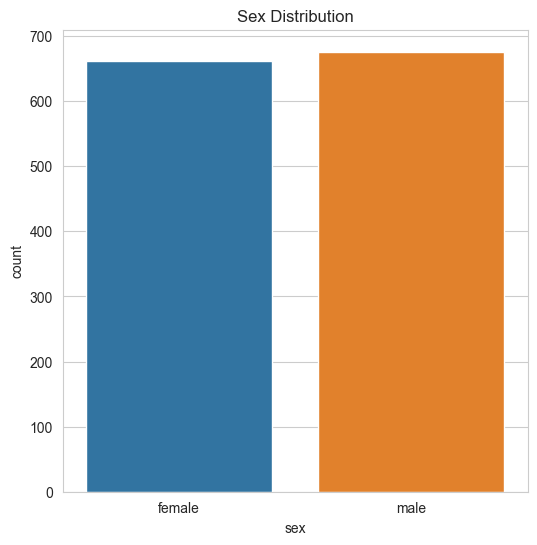

In [8]:
# Gender column
plt.figure(figsize=(6,6))
sns.countplot(x='sex', data=df,hue='sex')
plt.title('Sex Distribution')
plt.show()

<div style="font-size: 85%;">

* **Highly Balanced:** The dataset contains a nearly equal distribution between **female** and **male** individuals (both hovering around the 650–670 range).
* **No Gender Bias:** Since the sample is split almost perfectly 50:50, the predictive models will not suffer from bias toward a specific gender. This ensures a fair baseline when evaluating how gender affects medical charges.

</div>

In [9]:
df['sex'].value_counts()

sex
male      676
female    662
Name: count, dtype: int64

<Figure size 600x600 with 0 Axes>

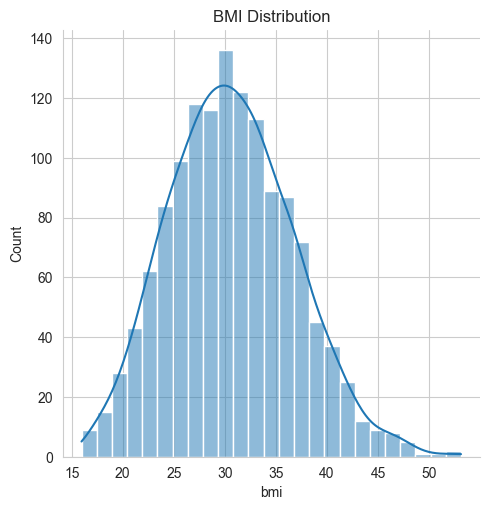

In [10]:
# bmi distribution
plt.figure(figsize=(6,6))
sns.displot(df['bmi'],kde=True)
plt.title('BMI Distribution')
plt.show()

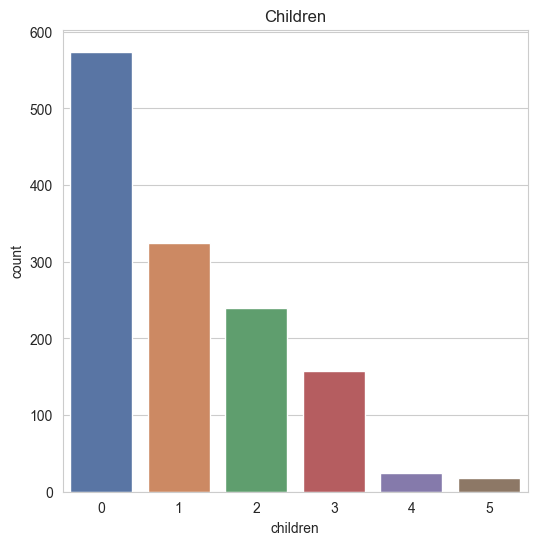

In [11]:
# children column
plt.figure(figsize=(6,6))
sns.countplot(x='children', data=df,hue='children', palette='deep',legend=False)
plt.title('Children')
plt.show()

<div style="font-size: 85%;">


* **Majority with No Children:** The distribution is heavily skewed toward **0 children** (nearly 600 individuals), making it the single largest group in the dataset.

* **Gradual Decline:** As the number of children increases from 1 to 5, the count drops sharply. Families with **4 or 5 children** are extremely rare.


</div>

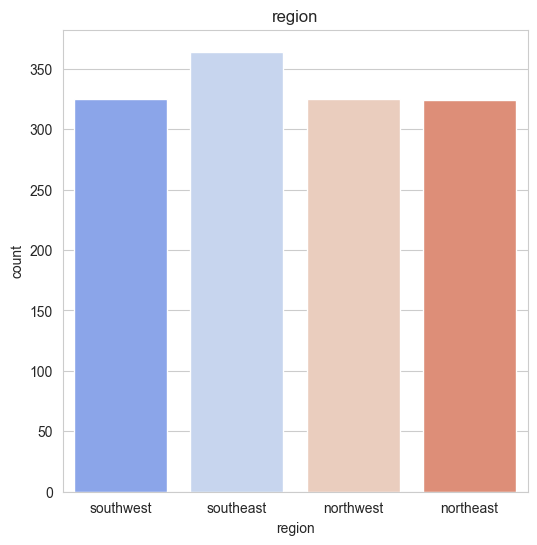

In [12]:
# region column
plt.figure(figsize=(6,6))
sns.countplot(x='region', data=df,hue='region', palette='coolwarm',legend=False)
plt.title('region')
plt.show()

<Figure size 600x600 with 0 Axes>

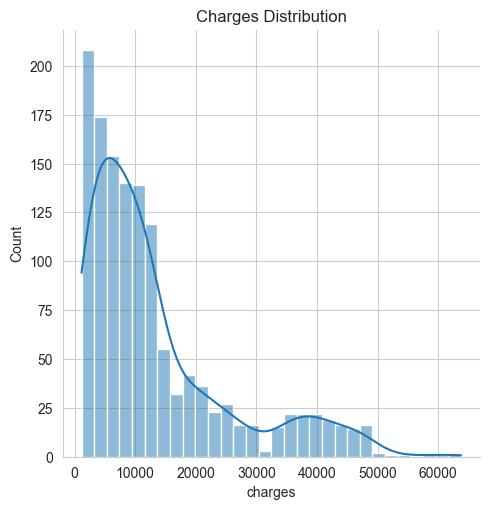

In [13]:
# distribution of charges value
plt.figure(figsize=(6,6))
sns.displot(df['charges'], kde=True)
plt.title('Charges Distribution')
plt.show()

<Axes: >

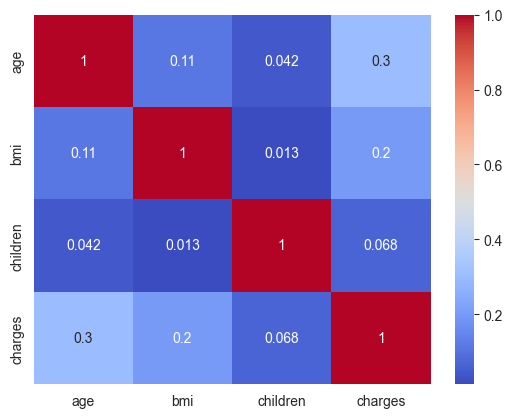

In [14]:
sns.heatmap(df[['age', 'bmi', 'children', 'charges']].corr(), annot=True, cmap='coolwarm')

### 3. Training Dataset

In [15]:
#Split data into features and target variable
X = df.drop(columns=['charges'])
y = df['charges']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#Saving train,test data to csv file
X_train.to_csv('../dataset/X_train.csv', index=False)
X_test.to_csv('../dataset/X_test.csv', index=False)
y_train.to_csv('../dataset/y_train.csv', index=False)
y_test.to_csv('../dataset/y_test.csv', index=False)    

In [16]:
# Encoding
X_train = X_train.copy()
X_test = X_test.copy()
for col in ['sex', 'smoker']:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])
    print(f"Classes for {col}: {le.classes_}")


ohe = OneHotEncoder(drop='first', sparse_output=False)

region_train_encoded = ohe.fit_transform(X_train[['region']])
region_test_encoded = ohe.transform(X_test[['region']])

columns_ohe = ohe.get_feature_names_out(['region'])
region_train_df = pd.DataFrame(region_train_encoded, columns=columns_ohe, index=X_train.index)
region_test_df = pd.DataFrame(region_test_encoded, columns=columns_ohe, index=X_test.index)

X_train = pd.concat([X_train, region_train_df], axis=1).drop(columns=['region'])
X_test = pd.concat([X_test, region_test_df], axis=1).drop(columns=['region'])



X_train.head()

Classes for sex: ['female' 'male']
Classes for smoker: ['no' 'yes']


,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest
560,46,0,19.95,2,0,1.0,0.0,0.0
1285,47,0,24.32,0,0,0.0,0.0,0.0
1142,52,0,24.86,0,0,0.0,1.0,0.0
969,39,0,34.32,5,0,0.0,1.0,0.0
486,54,0,21.47,3,0,1.0,0.0,0.0


In [17]:

model = LinearRegression()
model.fit(X_train, y_train)  # Mô hình sẽ học từ tập Train đã encode sạch sẽ

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# --- BƯỚC 7: ĐÁNH GIÁ HIỆU NĂNG MÔ HÌNH ---
def evaluate_model(y_true, y_pred, label="Tập dữ liệu"):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    print(f"=== ĐÁNH GIÁ {label.upper()} ===")
    print(f"R² Score (Độ giải thích): {r2:.4f}")
    print(f"MAE (Sai số tuyệt đối trung bình): ${mae:.2f}")
    print(f"RMSE (Sai số căn phương trung bình): ${rmse:.2f}\n")

# Chạy hàm đánh giá cho cả Train và Test
evaluate_model(y_train, y_train_pred, "Train")
evaluate_model(y_test, y_test_pred, "Test")

# --- BƯỚC EXTRA: XEM TRỌNG SỐ (HỆ SỐ) CỦA CÁC TÍNH NĂNG ---
coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

print("=== TRỌNG SỐ CỦA CÁC BIẾN ===")
print(coefficients.to_string(index=False))

=== ĐÁNH GIÁ TRAIN ===
R² Score (Độ giải thích): 0.7417
MAE (Sai số tuyệt đối trung bình): $4208.23
RMSE (Sai số căn phương trung bình): $6105.55

=== ĐÁNH GIÁ TEST ===
R² Score (Độ giải thích): 0.7836
MAE (Sai số tuyệt đối trung bình): $4181.19
RMSE (Sai số căn phương trung bình): $5796.28

=== TRỌNG SỐ CỦA CÁC BIẾN ===
         Feature  Coefficient
          smoker 23651.128856
        children   425.278784
             bmi   337.092552
             age   256.975706
             sex   -18.591692
region_northwest  -370.677326
region_southeast  -657.864297
region_southwest  -809.799354


### 4. Building a Predictive System

In [18]:
input_data = (31,1,25.74,0,1,0,1,0)

# changing input_data to a numpy array
input_data_as_numpy_array = np.asarray(input_data)

# reshape the array
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

prediction = model.predict(input_data_reshaped)

print(f'The insurance cost is ${prediction[0]:.2f}')

The insurance cost is $27686.46


c:\Users\VNSP8859\Data Learning\medical-insurance-cost-prediction\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
